In [5]:
import numpy as np
import pandas as pd

Carseats = pd.read_csv("Carseats.csv")
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [6]:
from sklearn.model_selection import train_test_split
Carseats_encoded = pd.get_dummies(Carseats, drop_first=True)

X = Carseats_encoded.drop(columns=['Sales'])
y = Carseats_encoded['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


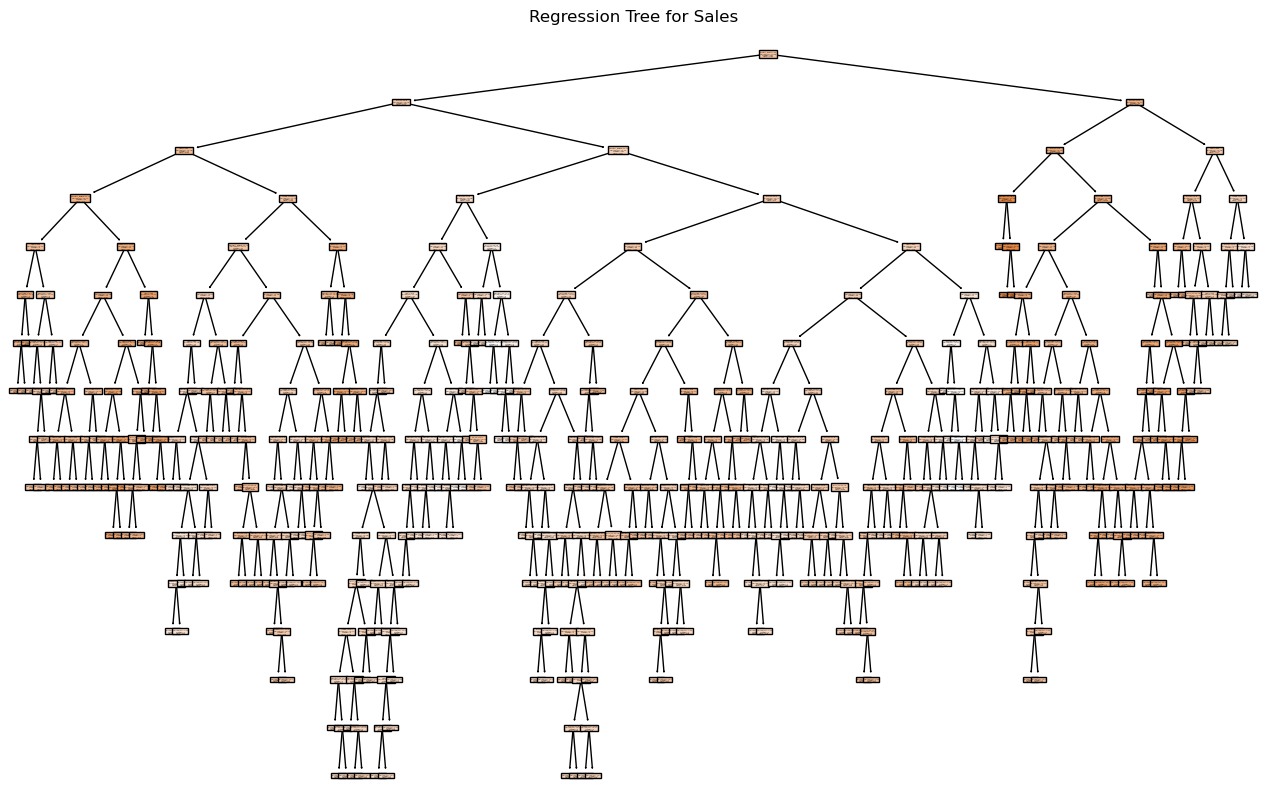

Test MSE (unpruned tree): 4.805344166666667


In [7]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(16, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True)
plt.title("Regression Tree for Sales")
plt.show()

# Test MSE
y_pred = tree_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print("Test MSE (unpruned tree):", test_mse)


Best alpha from CV: 0.04733571428571384
Test MSE (pruned tree): 4.552379794670005


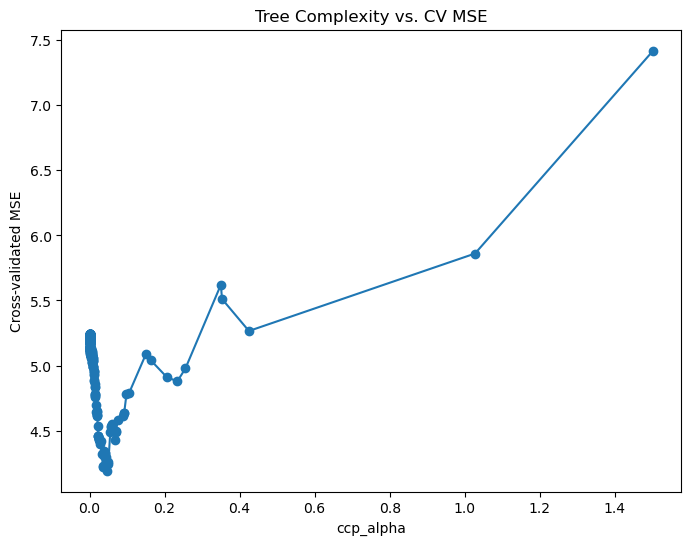

In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 用 cost-complexity pruning path 找 cp 值
path = tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

mse_list = []

# 對每一個 alpha 做 cross-validation
for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    scores = -cross_val_score(model, X_train, y_train,
                              scoring='neg_mean_squared_error', cv=10)
    mse_list.append(scores.mean())

# 找最佳 alpha
best_alpha = ccp_alphas[np.argmin(mse_list)]
print("Best alpha from CV:", best_alpha)

# Fit pruned tree
pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

# Test MSE for pruned model
y_pred_pruned = pruned_tree.predict(X_test)
test_mse_pruned = mean_squared_error(y_test, y_pred_pruned)
print("Test MSE (pruned tree):", test_mse_pruned)

# 画 alpha vs CV error
plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, mse_list, marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Tree Complexity vs. CV MSE")
plt.show()


In [9]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

# Bagging model (base estimator = decision tree)
bagging = BaggingRegressor(
    n_estimators=500,
    max_features=1.0,   # Bagging = 使用全部特徵
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

mse_bag = mean_squared_error(y_test, y_pred_bag)
print("Bagging Test MSE:", mse_bag)

# Bagging does not have feature_importance_
# So we use the average of all trees' importances
import numpy as np

feature_importances = np.mean(
    [tree.feature_importances_ for tree in bagging.estimators_],
    axis=0
)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nBagging Feature Importance:")
print(importance_df.head(10))


Bagging Test MSE: 2.4639861124333433

Bagging Feature Importance:
            Feature  Importance
4             Price    0.323418
7    ShelveLoc_Good    0.191917
5               Age    0.119317
0         CompPrice    0.106141
2       Advertising    0.071705
1            Income    0.052425
8  ShelveLoc_Medium    0.050947
3        Population    0.040526
6         Education    0.029405
9         Urban_Yes    0.007609


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',   # m = sqrt(p)
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Random Forest Test MSE:", mse_rf)

rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(rf_importance.head(10))


Random Forest Test MSE: 3.128058676713343

Random Forest Feature Importance:
             Feature  Importance
4              Price    0.247912
7     ShelveLoc_Good    0.144835
5                Age    0.134183
2        Advertising    0.098763
0          CompPrice    0.096908
3         Population    0.082691
1             Income    0.077456
6          Education    0.052375
8   ShelveLoc_Medium    0.038108
10            US_Yes    0.014371


In [21]:
import pandas as pd
from ISLP.bart import BART
from sklearn.metrics import mean_squared_error

# One-hot encoding
data_encoded = pd.get_dummies(Carseats, drop_first=True)

# 轉成 float
X = data_encoded.drop("Sales", axis=1).astype(float).values
y = data_encoded["Sales"].astype(float).values

# 切 train / test（如果你要跟前面一致）
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 訓練 BART
bart = BART()
bart.fit(X_train, y_train)

# 預測 & MSE
y_pred = bart.predict(X_test)
mse_bart = mean_squared_error(y_test, y_pred)
print("BART Test MSE:", mse_bart)


BART Test MSE: 1.3932949940576875
